In [ ]:
# Install / import everything you need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("All good!")

All good!


In [ ]:
# Load the Titanic dataset directly from the web
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# First look
print(df.shape)       # How many rows & columns?
df.head()             # See the first 5 rows

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


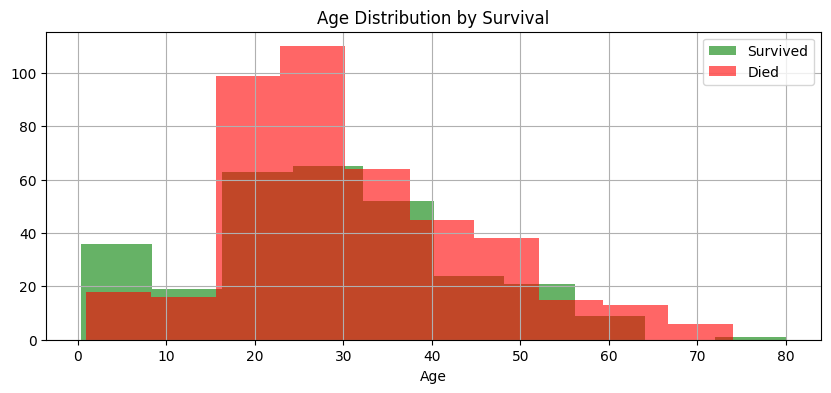

In [ ]:
# How many survived vs didn't?
df['Survived'].value_counts()
# 0 → 549 died
# 1 → 342 survived

# Survival rate by gender
df.groupby('Sex')['Survived'].mean()
# female → 0.74  (74% survived!)
# male   → 0.19  (only 19% survived)

# Survival rate by class
df.groupby('Pclass')['Survived'].mean()
# 1st class → 63%
# 2nd class → 47%
# 3rd class → 24%

# Visualise age distribution
plt.figure(figsize=(10,4))
df[df['Survived']==1]['Age'].hist(alpha=0.6, label='Survived', color='green')
df[df['Survived']==0]['Age'].hist(alpha=0.6, label='Died', color='red')
plt.legend()
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.show()

In [ ]:
# Check for missing values
df.isnull().sum()
# Age        → 177 missing  ← problem!
# Cabin      → 687 missing  ← too many, drop it
# Embarked   → 2 missing    ← easy to fix

# Fix 1: Fill missing Age with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fix 2: Fill missing Embarked with the most common port
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fix 3: Convert Sex from text to number
# female → 0, male → 1
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# Fix 4: Convert Embarked to numbers
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Select only the columns we'll use
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']
X = df[features]   # Input features (what the model sees)
y = df['Survived'] # Target (what the model predicts)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 6)
y shape: (891,)


/tmp/ipykernel_59187/3366410851.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_59187/3366410851.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% saved for testing
    random_state=42     # So results are reproducible
)

print(f"Training set: {X_train.shape[0]} passengers")
print(f"Test set:     {X_test.shape[0]} passengers")
# Training set: 712 passengers
# Test set:     179 passengers

Training set: 712 passengers
Test set:     179 passengers


In [ ]:
# Create the model
model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees voting together
    random_state=42
)

# Train it — this is the magic line
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


Accuracy: 84.36%


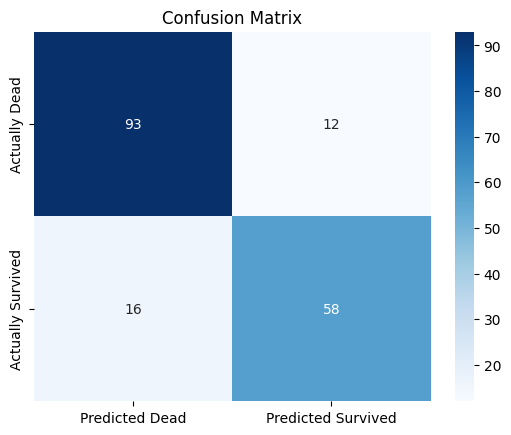

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# How accurate?
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
# → Accuracy: 82.68%

# Deeper look with a confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead','Predicted Survived'],
            yticklabels=['Actually Dead','Actually Survived'])
plt.title('Confusion Matrix')
plt.show()

# Full report
print(classification_report(y_test, y_pred))

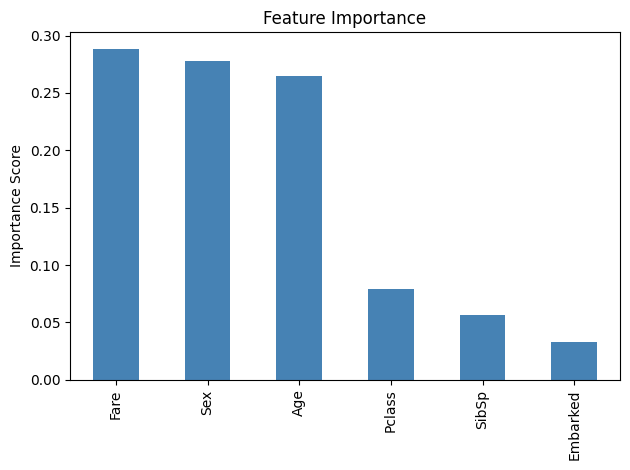

In [ ]:
# Which features mattered most?
importances = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

importances.plot(kind='bar', color='steelblue', title='Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Predict survival for a new passenger
new_passenger = pd.DataFrame({
    'Pclass':   [3],      # 3rd class
    'Sex':      [1],      # Male
    'Age':      [22],     # 22 years old
    'SibSp':    [1],      # Travelling with 1 sibling
    'Fare':     [7.25],   # Cheap ticket
    'Embarked': [0]       # Departed from Southampton
})

prediction = model.predict(new_passenger)
probability = model.predict_proba(new_passenger)

print(f"Survived: {'Yes' if prediction[0]==1 else 'No'}")
print(f"Survival probability: {probability[0][1]:.1%}")
# → Survived: No
# → Survival probability: 14.3%

Survived: No
Survival probability: 13.0%


In [ ]:
# Try more trees
model = RandomForestClassifier(n_estimators=500, random_state=42)

# Engineer new features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.') # Mr, Mrs, Miss, etc.

# Try different algorithms and compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    'Random Forest':    RandomForestClassifier(n_estimators=100),
    'Logistic Reg':     LogisticRegression(max_iter=200),
    'Decision Tree':    DecisionTreeClassifier()
}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"{name}: {acc:.2%}")

<>:7: SyntaxWarning: invalid escape sequence '\.'
<>:7: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_59187/3211444866.py:7: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.') # Mr, Mrs, Miss, etc.


Random Forest: 83.24%
Logistic Reg: 79.33%
Decision Tree: 78.77%
